In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [5]:
df = pd.read_csv('/content/marketing_campaign.csv', sep='\t')

In [6]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [8]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [9]:
df=df.dropna()

In [10]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [11]:
df['Age'] = 2026 - df['Year_Birth']
df['TotalSpent'] = df[
    ['MntWines','MntFruits','MntMeatProducts',
     'MntFishProducts','MntSweetProducts',
     'MntGoldProds']
].sum(axis=1)
df[['Age','TotalSpent']].head()

,Age,TotalSpent
0,69,1617
1,72,27
2,61,776
3,42,53
4,45,422


In [12]:
X = df[['Income','Age','TotalSpent','Recency']]
X.head()

,Income,Age,TotalSpent,Recency
0,58138.0,69,1617,58
1,46344.0,72,27,38
2,71613.0,61,776,26
3,26646.0,42,53,26
4,58293.0,45,422,94


In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
wcss=[]

for i in range(1,11):
    km=KMeans(n_clusters=i,random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

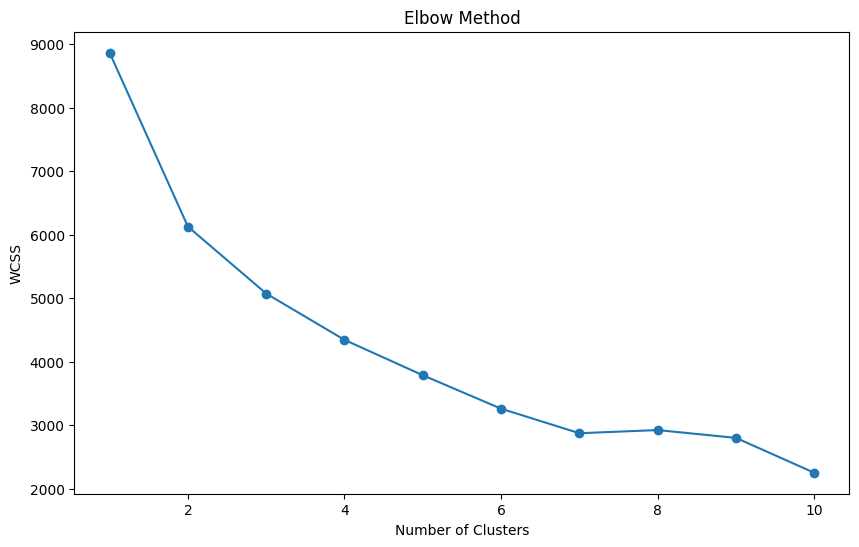

In [15]:
plt.figure(figsize=(10,6))
plt.plot(range(1,11),wcss,marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [16]:
for i in range(2,8):
    km=KMeans(n_clusters=i,random_state=42)
    labels=km.fit_predict(X_scaled)
    print("Clusters:", i,
          "Silhouette Score:",
          silhouette_score(X_scaled,labels))

Clusters: 2 Silhouette Score: 0.30875729180680617
Clusters: 3 Silhouette Score: 0.2598882538410596
Clusters: 4 Silhouette Score: 0.259905168078706
Clusters: 5 Silhouette Score: 0.2623722826152358
Clusters: 6 Silhouette Score: 0.2651659518651951
Clusters: 7 Silhouette Score: 0.27047547746351414


In [17]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

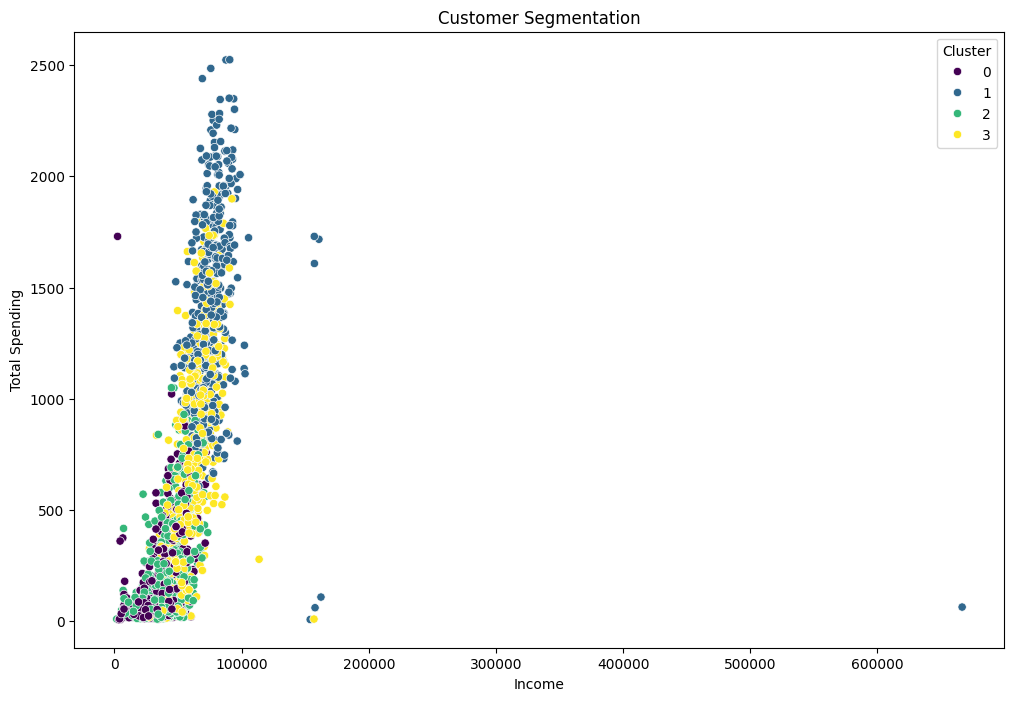

In [21]:
plt.figure(figsize=(12,8))
sns.scatterplot(
    x=df['Income'],
    y=df['TotalSpent'],
    hue=df['Cluster'],
    palette='viridis'
)
plt.title("Customer Segmentation")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.show()

In [22]:
df.groupby('Cluster')[
['Income','Age','TotalSpent','Recency']
].mean()

,Income,Age,TotalSpent,Recency
Cluster,,,,
0,34658.424191,50.177172,159.846678,26.744463
1,76910.344633,53.374765,1403.606403,56.384181
2,39972.582508,56.580858,220.856436,77.455446
3,61733.000000,70.378049,756.697154,32.591463


## Business Insights

Cluster 0:
High-income and high-spending premium customers.

Cluster 1:
Budget-conscious low spenders.

Cluster 2:
High-income low-spenders with upselling potential.

Cluster 3:
Inactive customers suitable for re-engagement campaigns.

Recommendations:
- Offer loyalty rewards to premium customers
- Provide discounts for budget customers
- Upsell premium products
- Launch re-engagement campaigns